In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


In [2]:
# ── Cell 2: Imports ───────────────────────────────────────────────────
import torch
import torch.nn as nn
import numpy as np
import IPython.display as ipd

from audiocraft.models import MusicGen
from audiocraft.modules.conditioners import ConditioningAttributes

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device :", device)
print("Torch version:", torch.__version__)

WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.1.0+cu121 with CUDA 1201 (you have 2.10.0+cu128)
    Python  3.10.13 (you have 3.10.19)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details
/home/ml/workspaces/yugesh/miniconda3/envs/yugesh/lib/python3.10/site-packages/xformers/triton/softmax.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float16 if _triton_softmax_fp16_enabled else None)
/home/ml/workspaces/yugesh/miniconda3/envs/yugesh/lib/python3.10/site-packages/xformers/triton/softmax.py:87: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backwar

Using device : cuda
Torch version: 2.10.0+cu128


In [3]:
# ── Cell 3: Load MusicGen ─────────────────────────────────────────────
model    = MusicGen.get_pretrained("small", device=device)
lm_model = model.lm

base_dtype = next(lm_model.parameters()).dtype
total_params = sum(p.numel() for p in lm_model.parameters())

print(f"Model dtype  : {base_dtype}")
print(f"Total params : {total_params:,}")

/home/ml/workspaces/yugesh/miniconda3/envs/yugesh/lib/python3.10/site-packages/audiocraft/models/musicgen.py:83: UserWarning: MusicGen pretrained model relying on deprecated checkpoint mapping. Please use full pre-trained id instead: facebook/musicgen-small
  warnings.warn(


Loading weights: 100%|██████████| 99/99 [00:00<00:00, 16290.16it/s]
/home/ml/workspaces/yugesh/miniconda3/envs/yugesh/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Model dtype  : torch.float32
Total params : 420,371,456


In [4]:

class LoRALinear(nn.Module):
    """
    Wraps an existing nn.Linear with LoRA adapters.

    Forward:  output = W*x  +  (B @ A @ x) * scale
              W is frozen.  Only A and B are trainable.

    At initialisation lora_B = zeros  →  delta = 0
    so the model output is IDENTICAL to the base model
    until any training happens.
    """
    def __init__(self, original_linear: nn.Linear, r: int = 16, alpha: int = 32):
        super().__init__()
        self.original = original_linear
        self.r        = r
        self.scale    = alpha / r

        in_f   = original_linear.in_features
        out_f  = original_linear.out_features
        dev    = original_linear.weight.device
        dtype  = original_linear.weight.dtype   # must match base model

        # Freeze original weights
        self.original.weight.requires_grad = False
        if self.original.bias is not None:
            self.original.bias.requires_grad = False

        # LoRA matrices — same device & dtype as the base layer
        self.lora_A = nn.Parameter(torch.randn(r, in_f,  device=dev, dtype=dtype) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_f, r, device=dev, dtype=dtype))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base_out = self.original(x)
        lora_out = (x @ self.lora_A.T @ self.lora_B.T) * self.scale
        return base_out + lora_out


def inject_lora(
    model: nn.Module,
    target_suffixes: tuple = ("out_proj", "linear1", "linear2"),
    r: int = 16,
    alpha: int = 32,
) -> nn.Module:
    """
    Walk every named module; replace nn.Linear layers whose name
    ends with one of target_suffixes with a LoRALinear wrapper.
    """
    replaced = 0
    for name, module in list(model.named_modules()):
        for suffix in target_suffixes:
            if name.endswith(suffix) and isinstance(module, nn.Linear):
                parts  = name.split(".")
                parent = model
                for part in parts[:-1]:
                    parent = getattr(parent, part)
                setattr(parent, parts[-1], LoRALinear(module, r=r, alpha=alpha))
                print(f"  ✓ {name}")
                replaced += 1
    print(f"\nTotal LoRA layers injected: {replaced}")
    return model

print("LoRA classes ready.")

LoRA classes ready.


In [5]:
for p in lm_model.parameters():
    p.requires_grad = False

print("All params frozen.")
print("Trainable before LoRA:", sum(p.numel() for p in lm_model.parameters() if p.requires_grad))

lm_model = inject_lora(
    lm_model,
    target_suffixes=("out_proj", "linear1", "linear2"),
    r=16,
    alpha=32,
)

trainable = sum(p.numel() for p in lm_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in lm_model.parameters())
print(f"\nTrainable : {trainable:,} / {total:,}  ({100*trainable/total:.3f}%)")

All params frozen.
Trainable before LoRA: 0
  ✓ transformer.layers.0.self_attn.out_proj
  ✓ transformer.layers.0.linear1
  ✓ transformer.layers.0.linear2
  ✓ transformer.layers.0.cross_attention.out_proj
  ✓ transformer.layers.1.self_attn.out_proj
  ✓ transformer.layers.1.linear1
  ✓ transformer.layers.1.linear2
  ✓ transformer.layers.1.cross_attention.out_proj
  ✓ transformer.layers.2.self_attn.out_proj
  ✓ transformer.layers.2.linear1
  ✓ transformer.layers.2.linear2
  ✓ transformer.layers.2.cross_attention.out_proj
  ✓ transformer.layers.3.self_attn.out_proj
  ✓ transformer.layers.3.linear1
  ✓ transformer.layers.3.linear2
  ✓ transformer.layers.3.cross_attention.out_proj
  ✓ transformer.layers.4.self_attn.out_proj
  ✓ transformer.layers.4.linear1
  ✓ transformer.layers.4.linear2
  ✓ transformer.layers.4.cross_attention.out_proj
  ✓ transformer.layers.5.self_attn.out_proj
  ✓ transformer.layers.5.linear1
  ✓ transformer.layers.5.linear2
  ✓ transformer.layers.5.cross_attention.out_p

In [6]:
# ── Cell 6: Sanity check ──────────────────────────────────────────────
layer = lm_model.transformer.layers[0].self_attn.out_proj

print("Layer type       :", type(layer).__name__)          # should be LoRALinear
print("lora_A dtype     :", layer.lora_A.dtype)
print("lora_A device    :", layer.lora_A.device)
print("original frozen  :", not layer.original.weight.requires_grad)  # should be True
print("lora_B is zeros  :", layer.lora_B.abs().sum().item() == 0.0)   # should be True

Layer type       : LoRALinear
lora_A dtype     : torch.float16
lora_A device    : cuda:0
original frozen  : True
lora_B is zeros  : True


In [7]:
# ── Cell 7: Inference config ──────────────────────────────────────────
# Edit your prompt here
PROMPT       = "Guitar music"
MAX_GEN_LEN  = 256    # tokens  (256 ≈ ~5 seconds)
TEMPERATURE  = 1.0
TOP_K        = 250

attributes = [ConditioningAttributes(text={"description": PROMPT})]
print(f"Prompt : {PROMPT}")
print(f"Length : {MAX_GEN_LEN} tokens")

Prompt : Guitar music
Length : 256 tokens


In [8]:
# ── Cell 8: Generate tokens ───────────────────────────────────────────
lm_model.eval()
lm_model.float()

with torch.no_grad():
    generated_tokens = lm_model.generate(
        prompt=None,
        conditions=attributes,
        max_gen_len=MAX_GEN_LEN,
        use_sampling=True,
        temp=TEMPERATURE,
        top_k=TOP_K,
    )  # shape: [B, K, T]

print("Generated tokens shape:", generated_tokens.shape)
# [1, 4, 256]  →  batch=1, codebooks=4, time=256

Generated tokens shape: torch.Size([1, 4, 256])


In [9]:
# ── Cell 9: Decode tokens → audio waveform ────────────────────────────
with torch.no_grad():
    audio_values = model.compression_model.decode(generated_tokens, None)
    # shape: [B, C, samples]  →  [1, 1, N]

audio_np = audio_values[0, 0].cpu().float().numpy()  # [N]
sample_rate = model.compression_model.sample_rate

print(f"Audio shape  : {audio_values.shape}")
print(f"Sample rate  : {sample_rate} Hz")
print(f"Duration     : {len(audio_np)/sample_rate:.2f} seconds")

Audio shape  : torch.Size([1, 1, 163840])
Sample rate  : 32000 Hz
Duration     : 5.12 seconds


In [10]:
# ── Cell 10: Play audio in notebook ───────────────────────────────────
ipd.display(ipd.Audio(audio_np, rate=sample_rate, autoplay=True))

In [11]:
def reward_fn(x):
    """
    Compute per-sequence reward.
    
    Args:
        x: Tensor of shape [B, T, S] (e.g., token scores, logits, or embeddings)
    
    Returns:
        rewards: Tensor of shape [B, 1, 1]
    """
    # Example: reward = mean over T and S
    x = x.float()
    x=1900-x
    rewards = x.mean(dim=(1,2), keepdim=True) /1024 # shape [B, 1, 1]
    
    
    # Optional: scale or clamp reward
    # rewards = torch.clamp(rewards, 0.0, 10.0)

    return rewards

In [12]:


optimizer = torch.optim.AdamW(
    [p for p in lm_model.parameters() if p.requires_grad],
    lr=1e-5,
    weight_decay=1e-2
)

optim_param_count = sum(p.numel() for group in optimizer.param_groups for p in group['params'])

print(f"Optimizer managing: {optim_param_count:,} params")  # should NOT be 300M+max_gen_length=256
num_iterations = 500
batch_size = 4
accum_steps = 2
alpha = 0.6  # smoothing factor for running mean
entropy_multiplier = 0.005
max_gen_length = 256

prompt_text = ["alpha wave generation please" for _ in range(batch_size)] 
# prompt_text = ["alpha wave generation please"] 

attributes = [ConditioningAttributes(text={"description": desc}) for desc in prompt_text]



Optimizer managing: 5,505,024 params


In [13]:
save_dir = "checkpoints"

try:
    start_iteration
    
except:
    start_iteration=0
    running_baseline=None
    lm_model.float()  #paxi hatauda hunxa first choti ko lagi ho
    losses = []
    rewards = []
    entropy_list = []
    lm_model.float()
    os.makedirs(save_dir, exist_ok=True)


# start_iteration=0
# running_baseline=None
# lm_model.float()  #paxi hatauda hunxa first choti ko lagi ho
# losses = []
# rewards = []
# entropy_list = []


os.makedirs(save_dir, exist_ok=True)
lm_model.float()

loss_accum = []
reward_accum = []
running_baseline_list = []
entropy_accum = []

for iteration in range(start_iteration,num_iterations):
    lm_model.eval()
    with torch.no_grad():
        generated_tokens = lm_model.generate(
            prompt=None,
            conditions=attributes,
            max_gen_len=max_gen_length,
            use_sampling=True,
            temp=0.8,
            top_k=128,
            
        )
    
    lm_model.train()
    lm_output = lm_model.compute_predictions(
        codes=generated_tokens,
        conditions=attributes,
        condition_tensors=None
    )

    logits = lm_output.logits      # [B, K, T, card]
    mask = lm_output.mask          # [B, K, T]

    logits = torch.nan_to_num(logits, nan=0.0)


    log_probs_all = torch.log_softmax(logits, dim=-1)
    token_log_probs = torch.gather(
        log_probs_all,
        dim=-1,
        index=generated_tokens.unsqueeze(-1)
    ).squeeze(-1)  

    token_log_probs = token_log_probs * mask.float()
    entropy = -(log_probs_all.exp() * log_probs_all).sum(-1)*mask.float()  # [B, K, T]
    entropy_accum.append(entropy.mean().item())



    reward = reward_fn(generated_tokens)
    reward=reward.detach().float()
    reward = reward.view(-1,1,1)
    reward_accum.append(reward)
    if running_baseline is None:
            running_baseline = reward.mean()

    
    advantage = reward - running_baseline
    loss = -(advantage * token_log_probs + entropy_multiplier*entropy).mean()
    (loss/accum_steps).backward()
    loss_accum.append(loss.item())

    if (iteration + 1) % accum_steps == 0 :
        reward_batch = torch.cat(reward_accum, dim=0)    # shape [accum_steps*B, 1, 1]
        reward_mean = reward_batch.mean().item()
        running_baseline = alpha * running_baseline + (1 - alpha) * reward_mean
        running_baseline_list.append(running_baseline)
        optimizer.step()       
        optimizer.zero_grad()     
        print(f"Iteration {iteration}, Loss: {loss.item()}, reward: {reward_mean}, running_baseline: {running_baseline}")  
        loss_mean = sum(loss_accum) / accum_steps
        entropy_mean = sum(entropy_accum) / accum_steps
        losses.append(loss_mean)
        rewards.append(reward_mean)
        entropy_list.append(entropy_mean)
        loss_accum=[]
        reward_accum = []

    

    if iteration % 30 ==0:  
         
        checkpoint = {
                "iteration": iteration,
                "model_state_dict": lm_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "losses": losses,
                "rewards": rewards,
                "running_baseline":running_baseline,
                "entropy_list": entropy_list

            }
        torch.save(checkpoint, os.path.join(save_dir, f"checkpoint_iter_{iteration}.pt"))

Iteration 1, Loss: 0.04858071729540825, reward: 0.7088830471038818, running_baseline: 0.70182204246521
Iteration 3, Loss: 0.2347836196422577, reward: 0.9315347671508789, running_baseline: 0.7937071323394775
Iteration 5, Loss: 0.010722208768129349, reward: 0.7855052947998047, running_baseline: 0.7904264330863953
Iteration 7, Loss: -0.08275840431451797, reward: 0.7198828458786011, running_baseline: 0.7622090578079224
Iteration 9, Loss: -0.07498429715633392, reward: 0.6450347900390625, running_baseline: 0.7153393626213074
Iteration 11, Loss: -0.1200692355632782, reward: 0.7066773176193237, running_baseline: 0.7118745446205139
Iteration 13, Loss: 0.004787598270922899, reward: 0.6903437376022339, running_baseline: 0.703262209892273
Iteration 15, Loss: 0.044997747987508774, reward: 0.6810065507888794, running_baseline: 0.6943599581718445
Iteration 17, Loss: -0.058757152408361435, reward: 0.6732287406921387, running_baseline: 0.6859074831008911
Iteration 19, Loss: 0.09903977811336517, reward:

KeyboardInterrupt: 

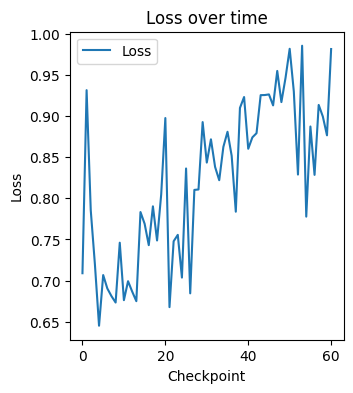

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(rewards, label="Loss")
plt.xlabel("Checkpoint")
plt.ylabel("Loss")
plt.title("Loss over time")
plt.legend()

In [20]:
# ── Cell 7: Inference config ──────────────────────────────────────────
# Edit your prompt here
PROMPT       = "alpha wave please"
MAX_GEN_LEN  = 256    # tokens  (256 ≈ ~5 seconds)
TEMPERATURE  = 1.0
TOP_K        = 250

attributes = [ConditioningAttributes(text={"description": PROMPT})]
print(f"Prompt : {PROMPT}")
print(f"Length : {MAX_GEN_LEN} tokens")

Prompt : alpha wave please
Length : 256 tokens


In [21]:
# ── Cell 8: Generate tokens ───────────────────────────────────────────
lm_model.eval()

with torch.no_grad():
    generated_tokens = lm_model.generate(
        prompt=None,
        conditions=attributes,
        max_gen_len=MAX_GEN_LEN,
        use_sampling=True,
        temp=TEMPERATURE,
        top_k=TOP_K,
    )  # shape: [B, K, T]

print("Generated tokens shape:", generated_tokens.shape)
# [1, 4, 256]  →  batch=1, codebooks=4, time=256

Generated tokens shape: torch.Size([1, 4, 256])


In [22]:
# ── Cell 9: Decode tokens → audio waveform ────────────────────────────
with torch.no_grad():
    audio_values = model.compression_model.decode(generated_tokens, None)
    # shape: [B, C, samples]  →  [1, 1, N]

audio_np = audio_values[0, 0].cpu().float().numpy()  # [N]
sample_rate = model.compression_model.sample_rate

print(f"Audio shape  : {audio_values.shape}")
print(f"Sample rate  : {sample_rate} Hz")
print(f"Duration     : {len(audio_np)/sample_rate:.2f} seconds")

Audio shape  : torch.Size([1, 1, 163840])
Sample rate  : 32000 Hz
Duration     : 5.12 seconds


In [23]:
# ── Cell 10: Play audio in notebook ───────────────────────────────────
ipd.display(ipd.Audio(audio_np, rate=sample_rate, autoplay=True))